<a href="https://colab.research.google.com/github/shreejal1/nsc_final/blob/main/implentations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import time
import math
import multiprocessing as mp
import dask.array as da
from dask.distributed import Client, LocalCluster
from numba import cuda
import matplotlib.pyplot as plt
import unittest

In [3]:
def mandelbrot_naive(width, height, max_iter=100):
    """
    Computes the Mandelbrot set using a naive, sequential nested loop.

    This function iterates point-by-point over the complex plane, calculating
    z = z^2 + c. It is intended to serve as a baseline for performance
    comparisons against parallelized and hardware-accelerated versions.

    Parameters:
    -----------
    width : int
        The number of pixels in the x-dimension.
    height : int
        The number of pixels in the y-dimension.
    max_iter : int, optional
        Maximum number of iterations before assuming the point is bounded (default 100).

    Returns:
    --------
    numpy.ndarray
        A 2D array of floats representing the normalized iteration count for each pixel.
    """
    result = np.zeros((height, width), dtype=float)
    x_coords = np.linspace(-2.0, 1.0, width)
    y_coords = np.linspace(-1.5, 1.5, height)

    for j in range(height):
        for i in range(width):
            c = complex(x_coords[i], y_coords[j])
            z = 0j
            for n in range(max_iter):
                if abs(z) > 2.0:
                    result[j, i] = n / max_iter
                    break
                z = z*z + c
            else:
                result[j, i] = 1.0
    return result

def mandelbrot_numpy(c_grid, max_iter=100):
    """
    Computes the Mandelbrot set using vectorized NumPy operations.
    """
    z = np.zeros_like(c_grid, dtype=complex)
    iterations = np.zeros(c_grid.shape, dtype=float)

    for n in range(max_iter):
        mask = np.abs(z) <= 2
        if not np.any(mask):
            break
        z[mask] = z[mask]**2 + c_grid[mask]
        iterations[mask] = n

    return iterations / max_iter

In [4]:
# --- Multiprocessing ---
def mandel_pixel_calc(c, max_iter):
    z = 0j
    for n in range(max_iter):
        if abs(z) > 2.0:
            return n / max_iter
        z = z*z + c
    return 1.0

def mandelbrot_multiprocessing(width, height, max_iter=100, processes=4, chunksize=100):
    x = np.linspace(-2.0, 1.0, width)
    y = np.linspace(-1.5, 1.5, height)
    X, Y = np.meshgrid(x, y)
    c_flat = (X + 1j*Y).flatten()

    with mp.Pool(processes=processes) as pool:
        result = pool.starmap(mandel_pixel_calc, [(c, max_iter) for c in c_flat], chunksize=chunksize)

    return np.array(result).reshape((height, width))

# --- Dask ---
def run_dask_mandelbrot(width, height, chunk_size, max_iter=100):
    x = da.linspace(-2.0, 1.0, width, chunks=chunk_size)
    y = da.linspace(-1.5, 1.5, height, chunks=chunk_size)
    X, Y = da.meshgrid(x, y)
    c_grid = X + 1j*Y

    mandel_dask = c_grid.map_blocks(mandelbrot_numpy, max_iter=max_iter, dtype=float)
    return mandel_dask.compute()

In [5]:
@cuda.jit
def mandelbrot_kernel(d_iterations, min_x, max_x, min_y, max_y, width, height, max_iter):
    """
    CUDA kernel to compute the Mandelbrot set on the GPU.
    """
    # 2D Grid/Block mapping
    x_idx, y_idx = cuda.grid(2)

    # Out-of-bounds check
    if x_idx < width and y_idx < height:
        pixel_size_x = (max_x - min_x) / width
        pixel_size_y = (max_y - min_y) / height

        c_real = min_x + x_idx * pixel_size_x
        c_imag = min_y + y_idx * pixel_size_y

        z_real = 0.0
        z_imag = 0.0

        for i in range(max_iter):
            if z_real * z_real + z_imag * z_imag >= 4.0:
                break

            temp_real = z_real * z_real - z_imag * z_imag + c_real
            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = temp_real

        d_iterations[y_idx, x_idx] = i / max_iter

def run_cuda_mandelbrot(width, height, threads_per_block=(16, 16), max_iter=100):
    # Data transfer: Allocate device memory
    d_iterations = cuda.device_array((height, width), dtype=np.float64)

    blocks_per_grid_x = math.ceil(width / threads_per_block[0])
    blocks_per_grid_y = math.ceil(height / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    cuda.synchronize() # Synchronization
    start_time = time.time()

    mandelbrot_kernel[blocks_per_grid, threads_per_block](
        d_iterations, -2.0, 1.0, -1.5, 1.5, width, height, max_iter
    )

    cuda.synchronize()
    execution_time = time.time() - start_time

    # Data transfer: Copy back to CPU
    h_iterations = d_iterations.copy_to_host()

    return h_iterations, execution_time

In [6]:
@cuda.jit
def mandelbrot_kernel(d_iterations, min_x, max_x, min_y, max_y, width, height, max_iter):
    """
    CUDA kernel to compute the Mandelbrot set on the GPU.
    """
    # 2D Grid/Block mapping
    x_idx, y_idx = cuda.grid(2)

    # Out-of-bounds check
    if x_idx < width and y_idx < height:
        pixel_size_x = (max_x - min_x) / width
        pixel_size_y = (max_y - min_y) / height

        c_real = min_x + x_idx * pixel_size_x
        c_imag = min_y + y_idx * pixel_size_y

        z_real = 0.0
        z_imag = 0.0

        for i in range(max_iter):
            if z_real * z_real + z_imag * z_imag >= 4.0:
                break

            temp_real = z_real * z_real - z_imag * z_imag + c_real
            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = temp_real

        d_iterations[y_idx, x_idx] = i / max_iter

def run_cuda_mandelbrot(width, height, threads_per_block=(16, 16), max_iter=100):
    # Data transfer: Allocate device memory
    d_iterations = cuda.device_array((height, width), dtype=np.float64)

    blocks_per_grid_x = math.ceil(width / threads_per_block[0])
    blocks_per_grid_y = math.ceil(height / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    cuda.synchronize() # Synchronization
    start_time = time.time()

    mandelbrot_kernel[blocks_per_grid, threads_per_block](
        d_iterations, -2.0, 1.0, -1.5, 1.5, width, height, max_iter
    )

    cuda.synchronize()
    execution_time = time.time() - start_time

    # Data transfer: Copy back to CPU
    h_iterations = d_iterations.copy_to_host()

    return h_iterations, execution_time

In [7]:
class TestMandelbrot(unittest.TestCase):
    def setUp(self):
        x = np.linspace(-2.0, 1.0, 5)
        y = np.linspace(-1.5, 1.5, 5)
        X, Y = np.meshgrid(x, y)
        self.c_grid = X + 1j * Y
        self.max_iter = 100

    def test_output_shape(self):
        """Test 1: Output shape matches input."""
        result = mandelbrot_numpy(self.c_grid, self.max_iter)
        self.assertEqual(result.shape, (5, 5))

    def test_known_bounded_point(self):
        """Test 2: Origin (0+0j) is strictly bounded."""
        point = np.array([[0 + 0j]])
        result = mandelbrot_numpy(point, self.max_iter)
        self.assertGreaterEqual(result[0, 0], 0.99)

    def test_known_divergent_point(self):
        """Test 3: Far point (2+2j) diverges immediately."""
        point = np.array([[2 + 2j]])
        result = mandelbrot_numpy(point, self.max_iter)
        self.assertEqual(result[0, 0], 0.0)

# Run tests
if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

...
----------------------------------------------------------------------
Ran 3 tests in 0.008s

OK


--- Benchmarking Mandelbrot (256x256) ---
Naive: 		0.1960s
NumPy: 		0.0414s
MP (4 cores):	0.5606s


INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: inproc://172.28.0.12/8895/1
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.worker:      Start worker at: inproc://172.28.0.12/8895/4
INFO:distributed.worker:         Listening to:          inproc172.28.0.12
INFO:distributed.worker:          Worker name:                          0
INFO:distributed.worker:         dashboard at:          172.28.0.12:34605
INFO:distributed.worker:Waiting to connect to: inproc://172.28.0.12/8895/1
INFO:distributed.worker:-------------------------------------------------
INFO:distributed.worker:              Threads:                          2
INFO:distributed.worker:               Memory:                  12.67 GiB
INFO:dist

Dask: 		0.2032s
CUDA (8, 8):	0.0007s
CUDA (16, 16):	0.0009s
CUDA (32, 32):	0.0016s
CUDA (32, 8):	0.0009s
--- Benchmarking Mandelbrot (512x512) ---


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Naive: 		0.7655s
NumPy: 		0.1578s


...

Dask: 		0.6014s
CUDA (8, 8):	0.0060s
CUDA (16, 16):	0.0060s
CUDA (32, 32):	0.0065s
CUDA (32, 8):	0.0063s
--- Benchmarking Mandelbrot (2048x2048) ---
Naive: 		16.8458s
NumPy: 		3.2658s


INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: inproc://172.28.0.12/8895/25
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.worker:      Start worker at: inproc://172.28.0.12/8895/28
INFO:distributed.worker:         Listening to:          inproc172.28.0.12
INFO:distributed.worker:          Worker name:                          0
INFO:distributed.worker:         dashboard at:          172.28.0.12:35127
INFO:distributed.worker:Waiting to connect to: inproc://172.28.0.12/8895/25
INFO:distributed.worker:-------------------------------------------------
INFO:distributed.worker:              Threads:                          2
INFO:distributed.worker:               Memory:                  12.67 GiB
INFO:distributed.worker:      Local Directory: /tmp/dask-scratch-space/worker-vin4kl6u
INFO:distributed.worker:----------------------------------------------

MP (4 cores):	34.3141s


INFO:distributed.scheduler:Remove client Client-9e3c48d0-4a3b-11f1-a2bf-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/8895/30; closing.
INFO:distributed.scheduler:Remove client Client-9e3c48d0-4a3b-11f1-a2bf-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-9e3c48d0-4a3b-11f1-a2bf-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1778175536.2605255') [0]
INFO:distributed.worker:Stopping worker at inproc://172.28.0.12/8895/28. Reason: worker-close
INFO:distributed.worker:Removing Worker plugin shuffle
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/8895/29; closing.
INFO:distributed.scheduler:Remove worker addr: inproc://172.28.0.12/8895/28 name: 0 (stimulus_id='handle-worker-cleanup-1778175536.2665234')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.core:Connection to inproc://172.28.0.12/8895/25 has been closed.
INFO:distributed.scheduler:Closin

Dask: 		1.8372s
CUDA (8, 8):	0.0228s
CUDA (16, 16):	0.0230s
CUDA (32, 32):	0.0237s
CUDA (32, 8):	0.0236s


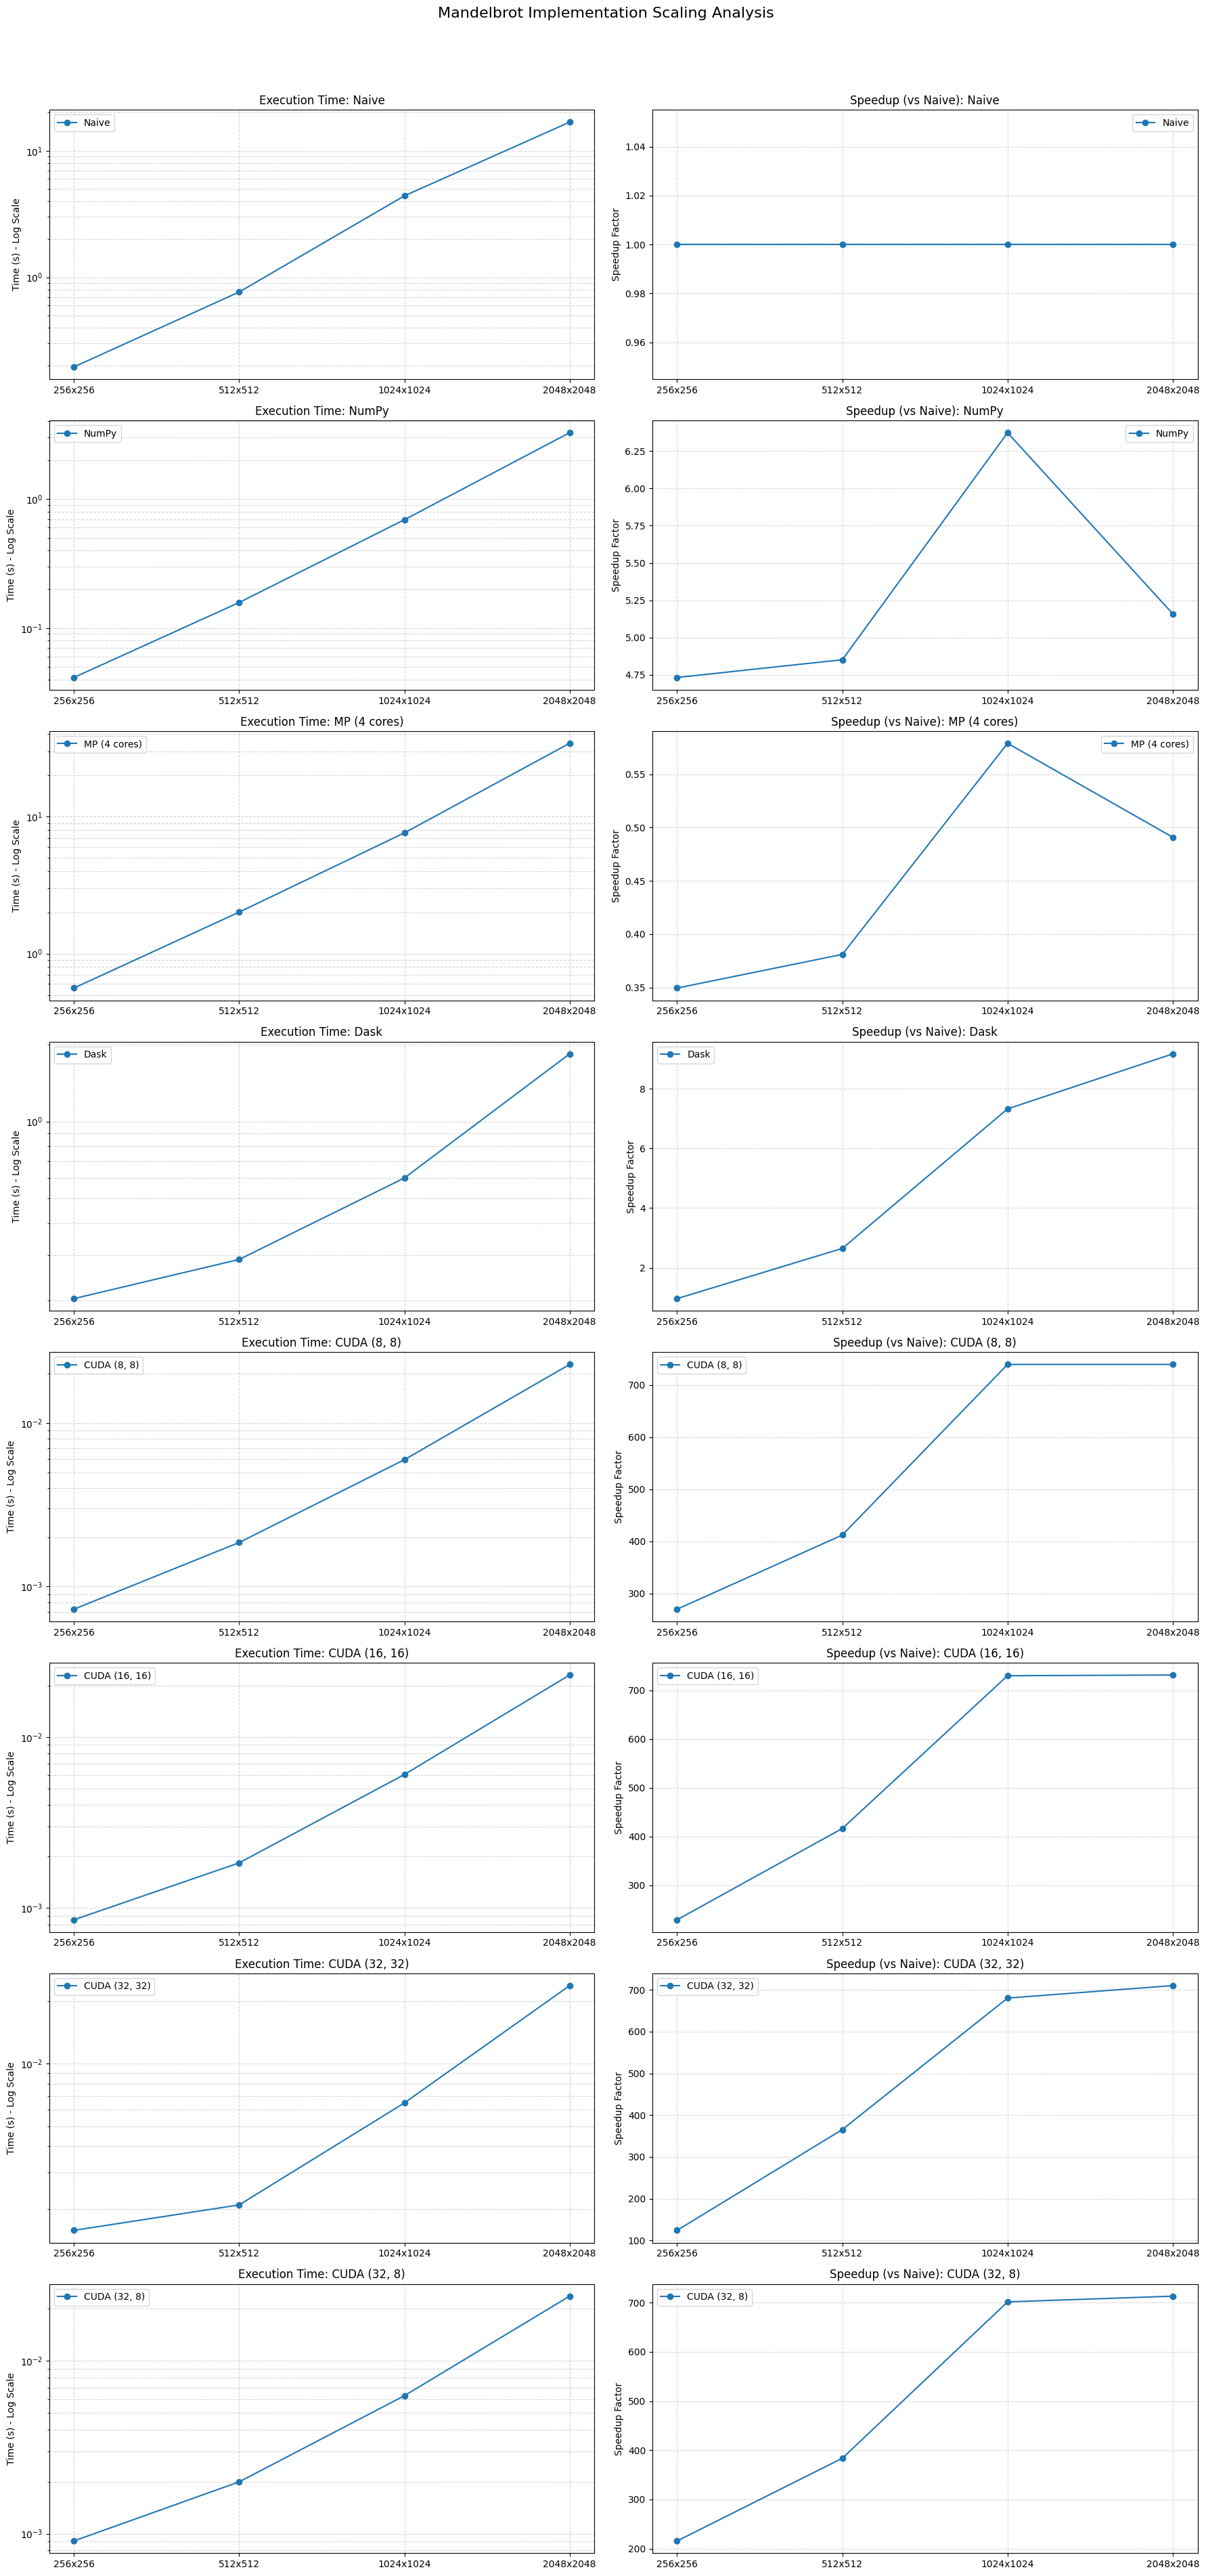

In [8]:
import numpy as np
import time
import math
import multiprocessing as mp
import dask.array as da
from dask.distributed import Client, LocalCluster
from numba import cuda
import matplotlib.pyplot as plt

# --- Function Definitions (copied from previous cells to resolve NameError) ---
def mandelbrot_naive(width, height, max_iter=100):
    """
    Computes the Mandelbrot set using a naive, sequential nested loop.

    This function iterates point-by-point over the complex plane, calculating
    z = z^2 + c. It is intended to serve as a baseline for performance
    comparisons against parallelized and hardware-accelerated versions.

    Parameters:
    -----------
    width : int
        The number of pixels in the x-dimension.
    height : int
        The number of pixels in the y-dimension.
    max_iter : int, optional
        Maximum number of iterations before assuming the point is bounded (default 100).

    Returns:
    --------
    numpy.ndarray
        A 2D array of floats representing the normalized iteration count for each pixel.
    """
    result = np.zeros((height, width), dtype=float)
    x_coords = np.linspace(-2.0, 1.0, width)
    y_coords = np.linspace(-1.5, 1.5, height)

    for j in range(height):
        for i in range(width):
            c = complex(x_coords[i], y_coords[j])
            z = 0j
            for n in range(max_iter):
                if abs(z) > 2.0:
                    result[j, i] = n / max_iter
                    break
                z = z*z + c
            else:
                result[j, i] = 1.0
    return result

def mandelbrot_numpy(c_grid, max_iter=100):
    """
    Computes the Mandelbrot set using vectorized NumPy operations.

    This function leverages NumPy's array operations to perform computations
    on the entire complex grid simultaneously, leading to better performance
    compared to naive, element-wise iteration.

    Parameters:
    -----------
    c_grid : numpy.ndarray
        A 2D array of complex numbers representing the grid points in the complex plane.
    max_iter : int, optional
        Maximum number of iterations before assuming the point is bounded (default 100).

    Returns:
    --------
    numpy.ndarray
        A 2D array of floats representing the normalized iteration count for each pixel.
    """
    z = np.zeros_like(c_grid, dtype=complex)
    iterations = np.zeros(c_grid.shape, dtype=float)

    for n in range(max_iter):
        mask = np.abs(z) <= 2
        if not np.any(mask):
            break
        z[mask] = z[mask]**2 + c_grid[mask]
        iterations[mask] = n

    return iterations / max_iter

# --- Multiprocessing ---
def mandel_pixel_calc(c, max_iter):
    """
    Calculates the Mandelbrot iteration count for a single complex point.

    This is a helper function designed for parallel processing, taking a single
    complex number `c` and returning its normalized iteration count.

    Parameters:
    -----------
    c : complex
        The complex number for which to calculate the Mandelbrot iteration.
    max_iter : int
        Maximum number of iterations before assuming the point is bounded.

    Returns:
    --------
    float
        The normalized iteration count for the given complex point.
    """
    z = 0j
    for n in range(max_iter):
        if abs(z) > 2.0:
            return n / max_iter
        z = z*z + c
    return 1.0

def mandelbrot_multiprocessing(width, height, max_iter=100, processes=4, chunksize=100):
    """
    Computes the Mandelbrot set using Python's multiprocessing module.

    This function distributes the calculation of individual pixels across multiple
    CPU cores, leveraging `multiprocessing.Pool` and `starmap` for parallel execution.

    Parameters:
    -----------
    width : int
        The number of pixels in the x-dimension.
    height : int
        The number of pixels in the y-dimension.
    max_iter : int, optional
        Maximum number of iterations before assuming the point is bounded (default 100).
    processes : int, optional
        The number of worker processes to use (default 4).
    chunksize : int, optional
        The number of tasks (pixels) each worker receives at a time (default 100).

    Returns:
    --------
    numpy.ndarray
        A 2D array of floats representing the normalized iteration count for each pixel.
    """
    x = np.linspace(-2.0, 1.0, width)
    y = np.linspace(-1.5, 1.5, height)
    X, Y = np.meshgrid(x, y)
    c_flat = (X + 1j*Y).flatten()

    with mp.Pool(processes=processes) as pool:
        result = pool.starmap(mandel_pixel_calc, [(c, max_iter) for c in c_flat], chunksize=chunksize)

    return np.array(result).reshape((height, width))

# --- Dask ---
def run_dask_mandelbrot(width, height, chunk_size, max_iter=100):
    """
    Computes the Mandelbrot set using Dask arrays for distributed computation.

    This function utilizes Dask to create a distributed array of complex numbers
    and then maps the `mandelbrot_numpy` function over its blocks, allowing for
    out-of-core and parallel processing.

    Parameters:
    -----------
    width : int
        The number of pixels in the x-dimension.
    height : int
        The number of pixels in the y-dimension.
    chunk_size : int
        The size of chunks for the Dask array, influencing parallelism and memory usage.
    max_iter : int, optional
        Maximum number of iterations before assuming the point is bounded (default 100).

    Returns:
    --------
    numpy.ndarray
        A 2D array of floats representing the normalized iteration count for each pixel.
    """
    x = da.linspace(-2.0, 1.0, width, chunks=chunk_size)
    y = da.linspace(-1.5, 1.5, height, chunks=chunk_size)
    X, Y = da.meshgrid(x, y)
    c_grid = X + 1j*Y

    mandel_dask = c_grid.map_blocks(mandelbrot_numpy, max_iter=max_iter, dtype=float)
    return mandel_dask.compute()

@cuda.jit
def mandelbrot_kernel(d_iterations, min_x, max_x, min_y, max_y, width, height, max_iter):
    """
    CUDA kernel to compute the Mandelbrot set on the GPU.

    This kernel is executed on the GPU, with each thread calculating the iteration
    count for a specific pixel in the Mandelbrot set. It performs the core
    z = z^2 + c calculation in parallel.

    Parameters:
    -----------
    d_iterations : numba.cuda.devicearray.DeviceNDArray
        Device array to store the normalized iteration counts for each pixel.
    min_x : float
        Minimum real value for the Mandelbrot plane.
    max_x : float
        Maximum real value for the Mandelbrot plane.
    min_y : float
        Minimum imaginary value for the Mandelbrot plane.
    max_y : float
        Maximum imaginary value for the Mandelbrot plane.
    width : int
        The total width of the image in pixels.
    height : int
        The total height of the image in pixels.
    max_iter : int
        Maximum number of iterations before assuming the point is bounded.
    """
    # 2D Grid/Block mapping
    x_idx, y_idx = cuda.grid(2)

    # Out-of-bounds check
    if x_idx < width and y_idx < height:
        pixel_size_x = (max_x - min_x) / width
        pixel_size_y = (max_y - min_y) / height

        c_real = min_x + x_idx * pixel_size_x
        c_imag = min_y + y_idx * pixel_size_y

        z_real = 0.0
        z_imag = 0.0

        for i in range(max_iter):
            if z_real * z_real + z_imag * z_imag >= 4.0:
                break

            temp_real = z_real * z_real - z_imag * z_imag + c_real
            z_imag = 2.0 * z_real * z_imag + c_imag
            z_real = temp_real

        d_iterations[y_idx, x_idx] = i / max_iter

def run_cuda_mandelbrot(width, height, threads_per_block=(16, 16), max_iter=100):
    """
    Executes the CUDA Mandelbrot kernel and manages data transfer.

    This function sets up the device memory, configures the grid and block
    dimensions for the CUDA kernel, launches the kernel, and transfers the
    results back to the host (CPU). It also measures the GPU execution time.

    Parameters:
    -----------
    width : int
        The width of the Mandelbrot image in pixels.
    height : int
        The height of the Mandelbrot image in pixels.
    threads_per_block : tuple, optional
        A tuple (threads_x, threads_y) specifying the dimensions of threads in each CUDA block (default (16, 16)).
    max_iter : int, optional
        Maximum number of iterations for the Mandelbrot calculation (default 100).

    Returns:
    --------
    tuple
        A tuple containing:
        - numpy.ndarray: The 2D array of normalized iteration counts on the CPU.
        - float: The measured execution time of the CUDA kernel in seconds.
    """
    # Data transfer: Allocate device memory
    d_iterations = cuda.device_array((height, width), dtype=np.float64)

    blocks_per_grid_x = math.ceil(width / threads_per_block[0])
    blocks_per_grid_y = math.ceil(height / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    cuda.synchronize() # Synchronization
    start_time = time.time()

    mandelbrot_kernel[blocks_per_grid, threads_per_block](
        d_iterations, -2.0, 1.0, -1.5, 1.5, width, height, max_iter
    )

    cuda.synchronize()
    execution_time = time.time() - start_time

    # Data transfer: Copy back to CPU
    h_iterations = d_iterations.copy_to_host()

    return h_iterations, execution_time


# --- Original Benchmarking Code ---
resolutions = [256, 512, 1024, 2048]
max_iter = 100

all_results = {}

for resolution in resolutions:
    print(f"--- Benchmarking Mandelbrot ({resolution}x{resolution}) ---")
    results = {}

    # 1. Naive Baseline
    start = time.time()
    img_naive = mandelbrot_naive(resolution, resolution, max_iter)
    results['Naive'] = time.time() - start
    print(f"Naive: \t\t{results['Naive']:.4f}s")

    # 2. NumPy Vectorized
    x = np.linspace(-2.0, 1.0, resolution)
    y = np.linspace(-1.5, 1.5, resolution)
    X, Y = np.meshgrid(x, y)
    c_grid = X + 1j*Y
    start = time.time()
    img_numpy = mandelbrot_numpy(c_grid, max_iter)
    results['NumPy'] = time.time() - start
    print(f"NumPy: \t\t{results['NumPy']:.4f}s")

    # 3. Multiprocessing
    start = time.time()
    img_mp = mandelbrot_multiprocessing(resolution, resolution, max_iter, processes=4, chunksize=1000)
    results['MP (4 cores)'] = time.time() - start
    print(f"MP (4 cores):\t{results['MP (4 cores)']:.4f}s")

    # 4. Dask
    client = Client(processes=False)
    start = time.time()
    img_dask = run_dask_mandelbrot(resolution, resolution, chunk_size=resolution//4, max_iter=max_iter)
    results['Dask'] = time.time() - start
    client.close()
    print(f"Dask: \t\t{results['Dask']:.4f}s")

    # 5. CUDA GPU Acceleration (All blocks)
    # Warmup for CUDA. Using a smaller fixed size here to avoid potentially long warmups for large resolutions.
    if resolution >= 256:
        _, _ = run_cuda_mandelbrot(256, 256, (16, 16), max_iter)
    block_sizes = [(8, 8), (16, 16), (32, 32), (32, 8)]

    for block in block_sizes:
        img_cuda, duration = run_cuda_mandelbrot(resolution, resolution, threads_per_block=block, max_iter=max_iter)
        label = f"CUDA {block}"
        results[label] = duration
        print(f"{label}:\t{duration:.4f}s")

    all_results[resolution] = results

# --- Visualizations for Scaling Analysis ---
methods = list(all_results[resolutions[0]].keys())

fig, axes = plt.subplots(len(methods), 2, figsize=(18, 5 * len(methods)))
fig.suptitle('Mandelbrot Implementation Scaling Analysis', fontsize=16)

for i, method in enumerate(methods):
    times_for_method = [all_results[res][method] for res in resolutions]
    naive_times = [all_results[res]['Naive'] for res in resolutions]
    speedups_for_method = [naive_times[j] / times_for_method[j] if times_for_method[j] != 0 else 0 for j in range(len(resolutions))]

    # Plot 1: Execution Time
    ax1 = axes[i, 0]
    ax1.plot(resolutions, times_for_method, marker='o', label=method)
    ax1.set_xscale('log', base=2)
    ax1.set_yscale('log')
    ax1.set_ylabel('Time (s) - Log Scale')
    ax1.set_title(f'Execution Time: {method}')
    ax1.set_xticks(resolutions)
    ax1.set_xticklabels([f'{r}x{r}' for r in resolutions])
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()

    # Plot 2: Speedup
    ax2 = axes[i, 1]
    ax2.plot(resolutions, speedups_for_method, marker='o', label=method)
    ax2.set_xscale('log', base=2)
    ax2.set_ylabel('Speedup Factor')
    ax2.set_title(f'Speedup (vs Naive): {method}')
    ax2.set_xticks(resolutions)
    ax2.set_xticklabels([f'{r}x{r}' for r in resolutions])
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()